# Assignment 6 -- Reed Baumgardner (Did Qs 2,3,4,6)
### Do Question 6, and three more questions of your choice.

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.stats import logistic
from scipy import stats
from scipy.stats import expon
from scipy.stats import nbinom
import seaborn as sns

In [158]:
df = pd.read_csv('./data/metabric.csv')
df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


### 1. Set review:

- Operations on sets (hints: sketch venn-type diagrams, and showing $A=B$ is the same as $A \subseteq B$ and $B \subseteq A$):
- $ (A \backslash B) \cup (A \cap B) = A $
- $ A \cup ( B \cap C) = (A \cup B) \cap (A \cup C)$
- $ A \backslash (B \cup C) = A\backslash B \cap A \backslash C $ and $A \backslash (B \cap C) = A \backslash B \cup A \backslash C$

- Plot the following sets: 
    - $A = \{x \in \mathbb{R}: x^2 -1 \ge 0 \}$ 
    - $B = \{ (x,y) \in \mathbb{R}^2: 3x -2y \ge 0 \}$
    - $C = \{ (x,y) \in \mathbb{R}^2: xy \ge 3 \}$
    - $D = \{ (x_1,x_2) \in \mathbb{R}^2: x_1 \ge 0, x_2 \ge 0, x_1 + x_2 \le 1 \}$
- The power set of $A$ is the set of all subsets of $A$, denoted $\mathcal{P}(A)$. What is the power set of $\{ 1, 2, 3 \}$? (Hint: The empty set is a subset of every set; the whole set is a subset of itself.)

### 2. Probability space basics:

- What are the outcomes for rolling a single, fair **THREE**-sided die? What's the set of all events? What are the probabilities of all the events?
- What about flipping a fair coin twice? (Hint: There are 4 outcomes, and $2^{4} = 16$ events.)
- What about rolling the **THREE**-sided die twice, and adding the results? Don't write down the set of all the possible events, but describe briefly what it looks like and how large it is. (Hint: There are 5 outcomes, and $2^{5}=32$ possible events.)

Obviously, a "three-sided die" doesn't exist, but this keeps you from spending a lot of time suffering in working out sets of events.

The outcomes are either 1, 2 or 3. This is the sample space.

The event space has $2^3 = 8$ possibilities, which should be made up of $\mathcal{F} = \{\emptyset, \{1\}, \{2\}, \{3\}, \{1,2\}, \{1,3\}, \{2,3\}, \{1,2,3\}\}$

The probability of each outcome is equal because it is a fair die, so $P(i) = \frac{1}{3}$

Flipping a fair coin can result in Heads (H) or Tails (T), so flipping it twice has the sample space $S =$ {$HH, HT, TH, TT$}

The event space has $2^4 = 16$ possibilites, for example: $\emptyset$, $\{HH\}$, $\{HT, TH\}$, $\{HH, HT, TH, TT\}$, etc.

The probability of each outcome is equally likely $P({x}) = \frac{1}{4}, \quad x \in X$

For rolling a three sided die twice and adding the results, the sample space is expanded from just rolling it once. In this instance, the random variable $Z = X_1 + X_2$ can only take on the values $S = $ {$2,3,4,5,6$}

The event space has $2^5 = 32$ possibilites, with each event corresponding to any subset of possible sums. For example, {$Z=2$}, {$Z=2 \text{ or } 3$}, {$Z=2 ,3, 4$} and so on.

The probability of any event  $A \subseteq S$, $P(A) = \sum_{z \in A} P(Z = z)$


### 3. Random Variable Basics

- Imagine rolling a fair single six-sided die. There are 6 outcomes, all equally likely. Derive the sample space and the space of events. What are the probabilities of the outcomes and events? 
- Consider a random variable that assigns the square root of the number of pips on the die to each outcome. Write code to simulate rolling a single six-sided die and computing the value of the random variable. Simulate 5000 rolls and plot the mass function and ECDF of the random variable.
- Imagine rolling two fair six-sided die. Consider a random variable that adds up the pips on the dice. There are 11 outcomes (2 , 3, ..., 12), but not all are equally likely. Derive the sample space and **describe** the space of events. What are the probabilities of the outcomes?
- Write code to simulate the random variable (rolling two six-sided die and adding the results together). Simulate 10000 rolls and plot the mass function and ECDF.

Sample Space \[
S = \{1, 2, 3, 4, 5, 6\}
\]

Each outcome \( x_i $\in$ S \) has equal probability:
\[
$P(X = x_i)$ = $\frac{1}{6}$, $\text{for } i = 1, 2, 3, 4, 5, 6$
\]

The event space, \( $\mathcal{F}$ \), is the set of all possible subsets of the sample space S.  
Formally, \( $\mathcal{F} = 2^S$ \), which represents the power set of S.  
Since the die has 6 sides, there are \( $2^6 = 64$ \) possible events.

Each event \( $A \subseteq S$ \) has probability:
\[
$P(A) = \sum_{x_i \in A} P(X = x_i)$
\]

We should define a random variable $Y$ that assigns the square root of the number of pips.

If $X$ represents the outcome of a die roll, then:

$$
Y = \sqrt{X}
$$

The possible outcomes of $Y$ are therefore:

$$
\{ \sqrt{1}, \sqrt{2}, \sqrt{3}, \sqrt{4}, \sqrt{5}, \sqrt{6} \}
$$

Since the die is fair, each outcome has equal probability:

$$
P(Y = \sqrt{k}) = \frac{1}{6}, \quad k = 1, 2, 3, 4, 5, 6
$$

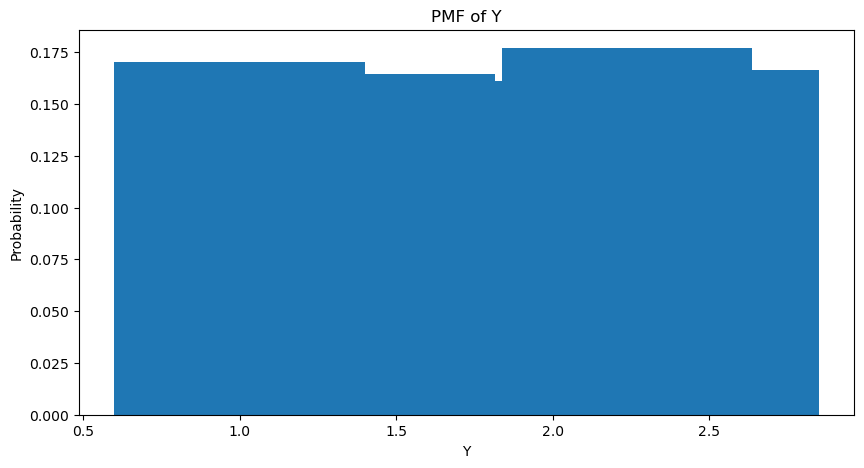

In [4]:
# Simulation

n = 5000
rolls = np.random.randint(1,7,n)

Y = np.sqrt(rolls)

vals, counts = np.unique(Y, return_counts=True)
pmf = counts/n

# Plotting PMF
plt.figure(figsize=(10,5))
plt.bar(vals, pmf)
plt.xlabel('Y')
plt.ylabel('Probability')
plt.title('PMF of Y')
plt.show()

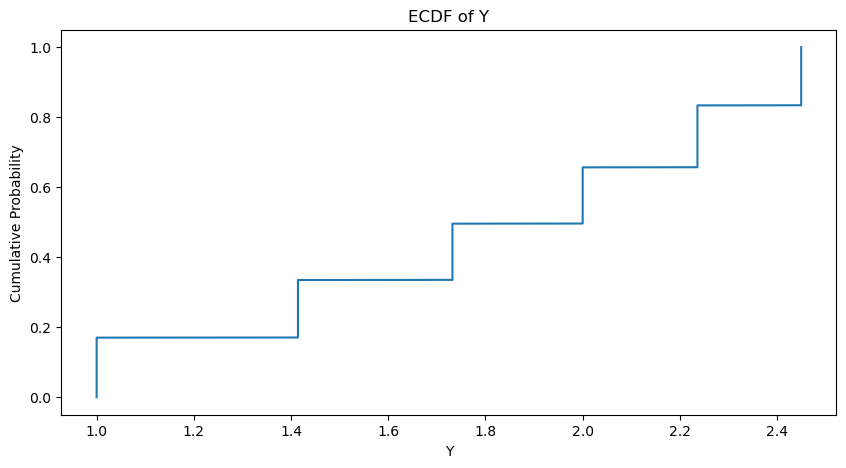

In [5]:
# Plotting ECDF

sorted_Y = np.sort(Y)
ecdf = np.arange(1, n+1)/n

plt.figure(figsize=(10,5))
plt.plot(sorted_Y, ecdf)
plt.xlabel('Y')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Y')
plt.show()

We can define the random variable for rolling two fair six sided die as $Z = X_1 + X_2$

The sample space for this is the same for rolling two fair six sided die, so it contains all ordered pairs of $(x_1,x_2)$ where each $x_i$ is in {1,2,3,4,5,6}

$S = (x_1,x_2) : x_1, x_2$ $\in$ {${1,2,3,4,5,6}$}

Thus, $ |S| = 36 $ and each outcome in S is equally likely with probability $P(x_1, x_2) = \frac{1}{36}$

However, the event space is not the same as the sample space, because each outcome of Z is not equally likely.

The possible values of Z are the integers 2 through 12

$ Z $ $\in$ {$2,3,4,5,6,7,8,9,10,11,12$}

So each value of Z corresponds to an event consisting of all $(x_1,x_2)$ pairs that sum to that value.

An event that corresponds to $Z=k$ can be shown by:

$ A_k = $ {$(x_1,x_2)$ $\in$ $ S : x_1 + x_2 = k $}

The probability of each event (value) is proportional to the number of pairs that sum to that value, which can be shown by

$ P(Z=k) = \frac{A_k}{36} $

Each value's probability is listed here:
(2 : 1/36 --
3 : 2/36 --
4 : 3/36 --
5 : 4/36 --
6 : 5/36 --
7 : 6/36 --
8 : 5/36 --
9 : 4/36 --
10 : 3/36 --
11 : 2/36 --
12 : 1/36)

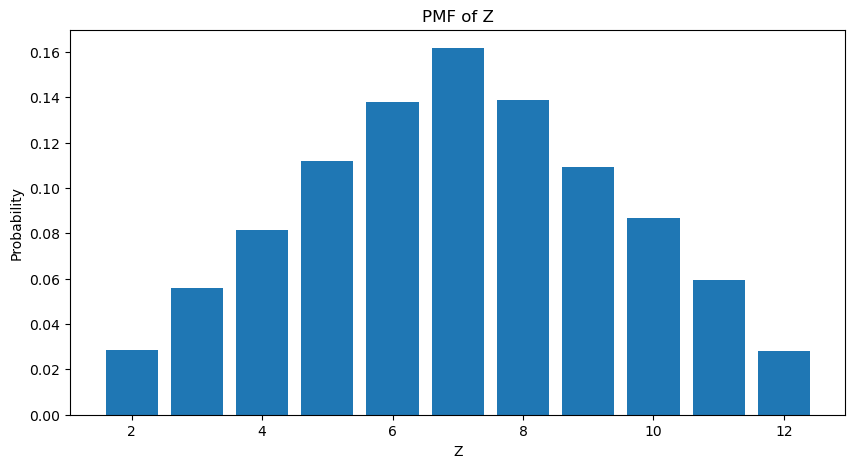

In [6]:
# Simulation
n = 10000
die1 = np.random.randint(1,7,n)
die2 = np.random.randint(1,7,n)

Z = die1 + die2

vals, counts = np.unique(Z, return_counts=True)
pmf = counts/n

# Plotting PMF
plt.figure(figsize=(10,5))
plt.bar(vals, pmf)
plt.xlabel('Z')
plt.ylabel('Probability')
plt.title('PMF of Z')
plt.show()

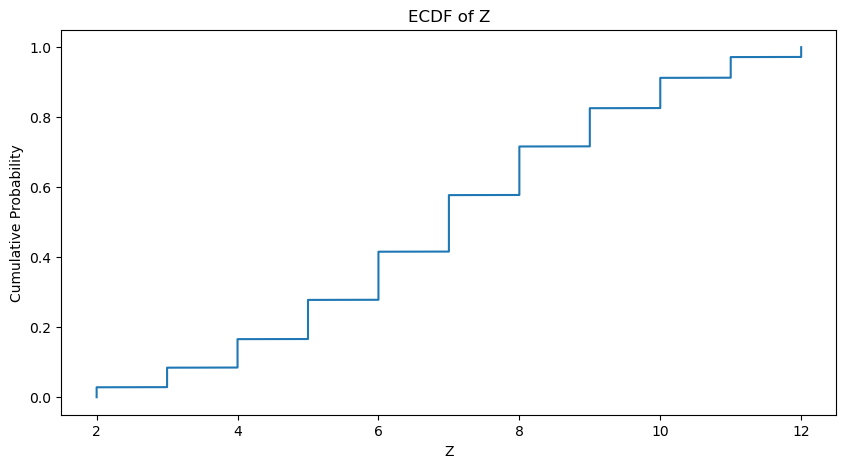

In [7]:
# Plotting ECDF

sorted_Z = np.sort(Z)
ecdf = np.arange(1, n+1)/n

plt.figure(figsize=(10,5))
plt.plot(sorted_Z, ecdf)
plt.xlabel('Z')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Z')
plt.show()

### 4. Roulette

This question will be easiest if you read the whole thing, and come up with a clear plan for how you'll write the code.

Roulette is a betting game. There are 37 possible outcomes: A green 0, and the numbers 1 to 36 in red and black. Here is a picture of the (American, not Euro, it has an extra green 00) betting board:

![Roulette](./src/euro_roulette.jpg)

To bet, you must pay a dollar, but then you get payouts that depend on how many slots are in your bet
- Basic bets:
    - Red or Black slots
    - Odd or Even slots
    - A single slots, like 20
- More complex bets:
    - Split: Two adjacent slots (e.g. {1,2})
    - Square: Four adjacent slots (e.g. {1,2,4,5})
    - Street: Three slots in a row (e.g. {1,2,3})
    - Line: Six slots (e.g. {1,2,3,4,5,6})
In general, you can only bet on 1, 2, 3, 4, 6 slots, 12 slots, or 18 slots. If your bet occurs when the wheel is spun, you gain 36/K-1 where $K$ is the number of slots you bet on; if not, you lose a dollar and get -1.

- Write code to model spinning the roulette wheel, including the colors and numbers (you could make two lists of number and color and draw a random number between 0 and 37... or use a dataframe with color and number variables and sample it... or use a dict with key to number/color pairs...)
- Describe the probability space associated with the roulette wheel: Outcomes, events, probabilities (If there are 37 outcomes, there are $2^{37}= 137,438,953,472$ events, by the way)
- You wrote code to generate a spin of the roulette wheel. Now write a function that takes a basic or complex bet as an argument, and returns the result for the player (win or lose, and the payout 36/K-1 or -1)
- Simulate betting on red, betting on odd, betting on 7, a split, and a line 1000 times each.
- Compute the average values for the bets you just simulated. What are the expected average payoffs?

In [18]:
def roll():
    red_num = {1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36}
    black_num = {2,4,6,8,10,11,13,15,17,20,22,24,26,28,29,31,33,35}
    
    num = random.randint(0,36)
    if num == 0:
        color = 'green'
    elif num in red_num:
        color = 'red'
    else:
        color = 'black'
    roll = [color, num]
    return roll

roll()

['black', 28]

The sample space contains every slot in the wheel in which the ball can land 0-36, with 18 red, 18 black and 1 green pocket. The colors do not change and therefore are permanently mapped to a number, not complicating the sample space.

The event space is the set of all possible events, which would be $2^{37}= 137,438,953,472$

On a fair wheel, every outcome is equally likely at $P(X_i) = \frac{1}{37}$

That is for when the set of outcomes is numbers 0-36, but a bet may also be on color, even/odd, splits, squares, lines etc.

Both Evens and Odds, since neither include 0, has the set of {${2,4,6 \dots 36}$} or {${1,3,5, \dots 35}$}, making the probability of an even or odd event $\frac{18}{37}$

Like even and odds, red and black have the same odds ($\frac{18}{37}$) because 0 is green (0 has probability $\frac{1}{37}$ as any other one number)

For splits, streets, etc, the probability would be equivalent to the sum of the probability of all numbers in the bet. If you split, it is two numbers and therefore probability is $\frac{2}{37}$. Basically, the length of the list of numbers bet (let's call it 'bet') in a given bet $P(len(bet)) = \frac{len(bet)}{37}$

In [80]:
def check_bet(bet):

    red_num = {1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36}
    black_num = {2,4,6,8,10,11,13,15,17,20,22,24,26,28,29,31,33,35}
    odd_num = {1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35}
    even_num = {2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36}

    if not isinstance(bet, list):
        raise TypeError("Input must be a list, e.g. ['red'] or [5,6,7].")
    
    spin = roll()
    color = spin[0]
    num = spin[1]

    if bet == ['red']:
        winning_nums = red_num
    elif bet == ['black']:
        winning_nums = black_num
    elif bet == ['odd']:
        winning_nums = odd_num
    elif bet == ['even']:
        winning_nums = even_num
    else:
        winning_nums = set()
        for i in bet:
            if isinstance(i, int) and 0 <= i <= 36:
                winning_nums.add(i)
            else:
                raise TypeError("All numeric bets must be integers between 0 and 36.")

    if num in winning_nums:
        return [spin, 'WIN!', (36/len(winning_nums)) - 1]
    else:
        return [spin, 'LOSE!', -1]

In [145]:
# Trying check_bet() on single bets to make sure it works

print(check_bet(['red']))
print(check_bet([6,7]))

[['red', 30], 'WIN!', 1.0]
[['red', 7], 'WIN!', 17.0]


In [79]:
# Playing

## Red
total = 0
for i in range(1000):
    total += check_bet(['red'])[2]
print('Betting on Red:', total/1000)

## Odd
total = 0
for i in range(1000):
    total += check_bet(['odd'])[2]
print('Betting on Odd:', total/1000)

## 7
total = 0
for i in range(1000):
    total += check_bet([7])[2]
print('Betting on 7:', total/1000)

## Split
total = 0
for i in range(1000):
    total += check_bet([6,7])[2]
print('Betting on Split:', total/1000)

## Line
total = 0
for i in range(1000):
    total += check_bet([1,2,3,4,5,6])[2]
print('Betting on Line:', total/1000)

Betting on Red: -0.006
Betting on Odd: -0.092
Betting on 7: -0.064
Betting on Split: -0.064
Betting on Line: 0.008


### 5. CDF and PDF Basics

- Verify the following functions are distribution functions and compute their density functions. Plot the distribution and density.

1. $F(x) = \begin{cases}
0, & x \le 0 \\
\sqrt{x}, & 0 \le x \le 1 \\
1, & x \ge 1 
\end{cases}
$
2. $F(x) = \dfrac{1}{1+e^{-x}}$
3. For $ a < b < c$,
$
F(x) = \begin{cases}
0, & x \le 0 \\
\frac{(x-a)^2}{(b-a)(b-c)}, & a \le x \le c \\
1 - \frac{(b-x)^2}{(b-a)(b-c)}, & c < x < b \\
1, & x \ge b
\end{cases}
$
4. $ F(x) = \begin{cases}
0, & x <0 \\
1 - e^{-x}, & x>0
\end{cases}
$
5. $ F(x) = \begin{cases}
0, & x \le 0 \\
x, & 0 < x < 1\\
1, & x \ge 1
\end{cases}
$

### 6. Some Common Distributions

For the following distributions:
- Determine the support
- Compute the density from the distribution for the logistic and exponential distributions (take a derivative)
- Plot the density and distribution for a variety of parameter values
- Take a sample of 1000 draws $(x_1, x_2, ..., x_{1000})$ from the distribution, plot a KDE and ECDF, visually compare with the theoretical pdf/cdf
- Find an example of this general type of PDF/CDF from the Metabric cancer data

You can use https://docs.scipy.org/doc/scipy/reference/stats.html to generate values for the pdf/cdf and generate samples of random variates.


- Logistic distribution (similar to normal): 
$$
F(x; \sigma) = \dfrac{1}{1+e^{-x/\sigma}} 
$$
with $\sigma >0$.
- Exponential distribution (similar to log-normal):
$$
F_X(x) = \begin{cases}
0, & x<0 \\
1 - e^{-\lambda x}, & x \ge 0,
\end{cases}
$$
with $\lambda > 0$.
- Negative Binomial (similar to Poisson): The probability mass function for positive integers is:
$$
f(k;r,p) = \dfrac{(k+r-1)!}{k!(r-1)!}(1-p)^k p^r, \quad \text{ for $k=0,...n$}
$$
You can interpret this as follows: Flip a coin that comes up heads with probability $p$ until you get $r$ heads, and then stop. What is the probability of stopping at each $k=0,1,2,...$?
- Categorical (similar to Bernoulli): The probability mass function over $k = 1, 2, ..., K$ categories is
$$
f(k;p_1,...,p_K) = p_1^{k=1}p_2^{k=2}...p_K^{k=K}
$$
where $0 \le p_i \le 1$ and $ \sum_{k=1}^K p_k = 1$.


## Logistic

### Support
Since $F(x)$ is defined for all real $x$, the support is $(-\infty,\infty)$

### Density

We take the derivative if the CDF:

$$
f(x; \sigma) = \frac{e^{-x/\sigma}}{\sigma \left(1 + e^{-x/\sigma}\right)^2}, \quad x \in \mathbb{R},\ \sigma > 0
$$

### Plot PDF and CDF

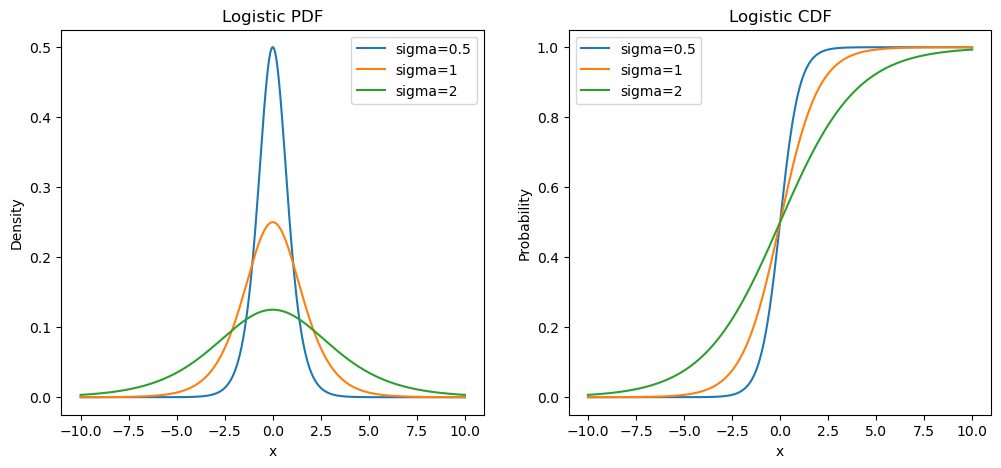

In [149]:
x = np.linspace(-10, 10, 500)
sigmas = [0.5, 1, 2]

plt.figure(figsize=(12,5))

# PDF
plt.subplot(1,2,1)
for s in sigmas:
    plt.plot(x, logistic.pdf(x, scale=s), label=f'sigma={s}')
plt.title('Logistic PDF')
plt.xlabel('x'); plt.ylabel('Density')
plt.legend()

# CDF
plt.subplot(1,2,2)
for s in sigmas:
    plt.plot(x, logistic.cdf(x, scale=s), label=f'sigma={s}')
plt.title('Logistic CDF')
plt.xlabel('x'); plt.ylabel('Probability')
plt.legend()
plt.show()

### Simulation, KDE + ECDF

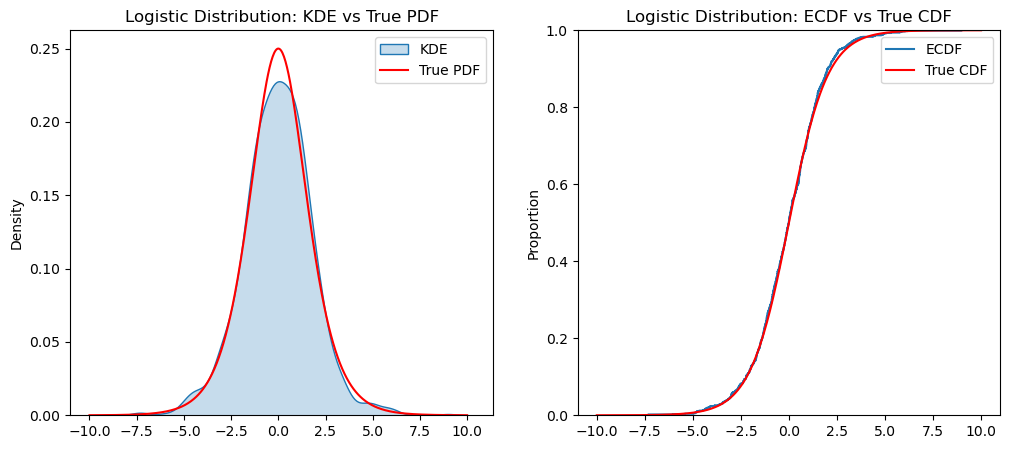

In [151]:
np.random.seed(67)
samples = logistic.rvs(scale=1, size=1000)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.kdeplot(samples, fill=True, label='KDE')
plt.plot(x, logistic.pdf(x, scale=1), color='r', label='True PDF')
plt.title('Logistic Distribution: KDE vs True PDF')
plt.legend()

plt.subplot(1,2,2)
sns.ecdfplot(samples, label='ECDF')
plt.plot(x, logistic.cdf(x, scale=1), color='r', label='True CDF')
plt.title('Logistic Distribution: ECDF vs True CDF')
plt.legend()
plt.show()

### Metabric Example

Age at Diagnosis may best demonstrate this distribution.

Estimated logistic parameters: loc = 60.8296, scale = 7.5797


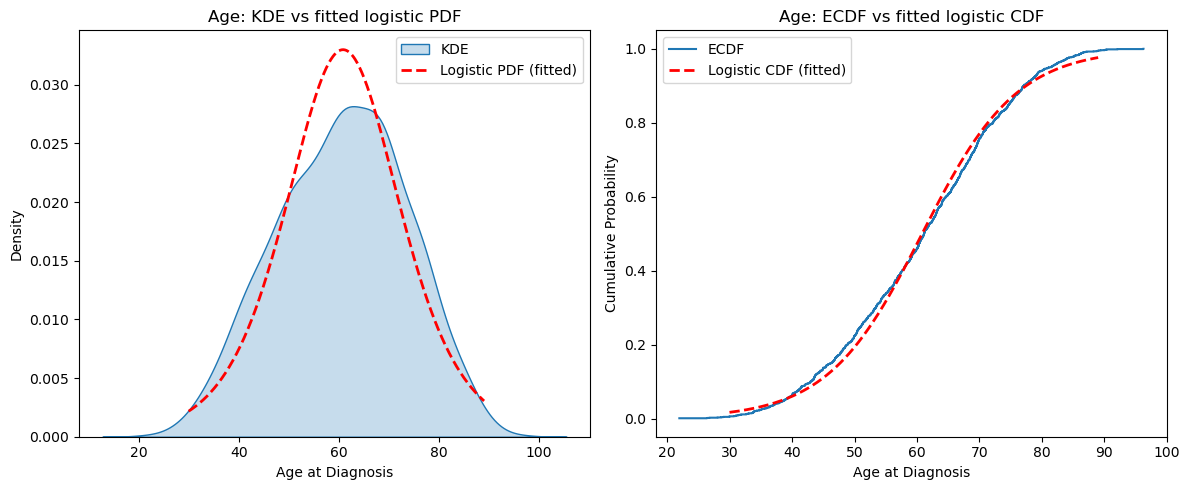

In [163]:
col = 'Age at Diagnosis'
x = df[col].dropna().astype(float).values


loc_hat, scale_hat = None, None
try:
    params = stats.logistic.fit(x)
    loc_hat, scale_hat = params[0], params[1]
except Exception as e:
    loc_hat, scale_hat = stats.logistic.fit(x)
    
print(f"Estimated logistic parameters: loc = {loc_hat:.4f}, scale = {scale_hat:.4f}")

# KDE vs theoretical PDF
xx = np.linspace(np.percentile(x, 0.5), np.percentile(x, 99.5), 400)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.kdeplot(x, fill=True, label='KDE')
plt.plot(xx, stats.logistic.pdf(xx, loc=loc_hat, scale=scale_hat), 'r--', lw=2, label='Logistic PDF (fitted)')
plt.title('Age: KDE vs fitted logistic PDF')
plt.xlabel(col); plt.ylabel('Density'); plt.legend()

# ECDF vs theoretical CDF
plt.subplot(1,2,2)

xs = np.sort(x)
ys = np.arange(1, len(xs)+1) / len(xs)
plt.step(xs, ys, where='post', label='ECDF')
plt.plot(xx, stats.logistic.cdf(xx, loc=loc_hat, scale=scale_hat), 'r--', lw=2, label='Logistic CDF (fitted)')
plt.title('Age: ECDF vs fitted logistic CDF')
plt.xlabel(col); plt.ylabel('Cumulative Probability'); plt.legend()

plt.tight_layout()
plt.show()

## Exponential

### Support
The CDF does not support negative values, so the support is $[0,\infty]$

### Density

We take the derivative of the CDF:

$$
f(x; \lambda) =
\begin{cases} 
\lambda e^{-\lambda x} & x \ge 0, \\
0 & x < 0.
\end{cases}
$$

### Plot PDF and CDF

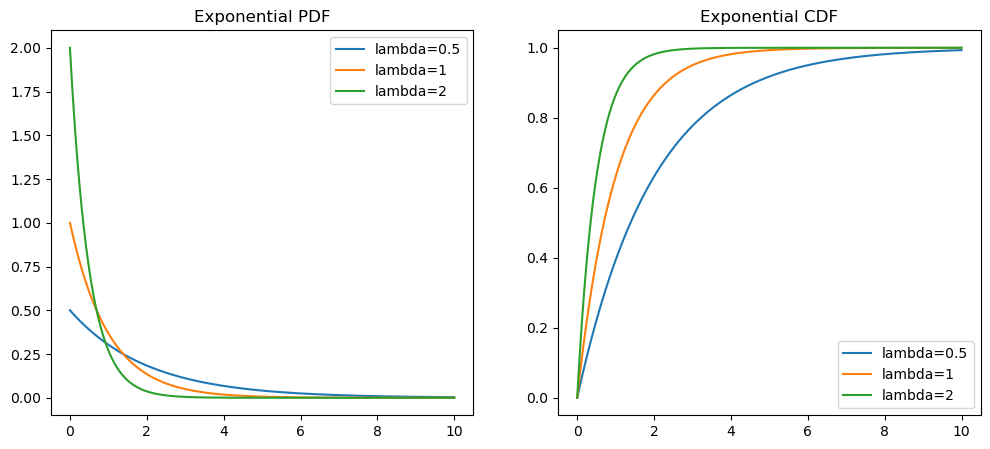

In [166]:
x = np.linspace(0, 10, 500)
lambdas = [0.5, 1, 2]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for l in lambdas:
    plt.plot(x, expon.pdf(x, scale=1/l), label=f'lambda={l}')
plt.title('Exponential PDF')
plt.legend()

plt.subplot(1,2,2)
for l in lambdas:
    plt.plot(x, expon.cdf(x, scale=1/l), label=f'lambda={l}')
plt.title('Exponential CDF')
plt.legend()
plt.show()

### Simulation, KDE + ECDF

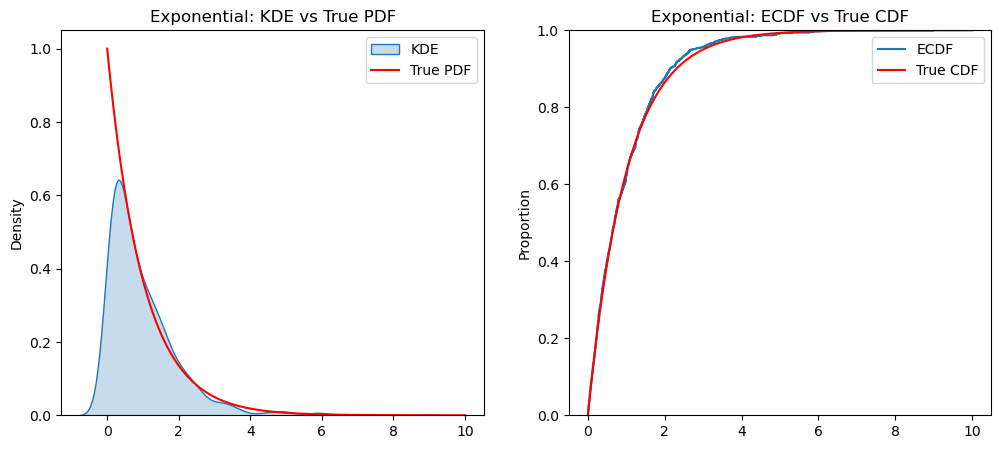

In [168]:
np.random.seed(67)
samples = expon.rvs(scale=1, size=1000)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.kdeplot(samples, fill=True, label='KDE')
plt.plot(x, expon.pdf(x, scale=1), color='r', label='True PDF')
plt.title('Exponential: KDE vs True PDF')
plt.legend()

plt.subplot(1,2,2)
sns.ecdfplot(samples, label='ECDF')
plt.plot(x, expon.cdf(x, scale=1), color='r', label='True CDF')
plt.title('Exponential: ECDF vs True CDF')
plt.legend()
plt.show()

### Metabric Example

I think overall survival may be the best representation for this distribution if you assume that survival decays exponentially. Let's check.

Scipy fit (with loc=0): scale = 129.094291 => lambda = 0.007746


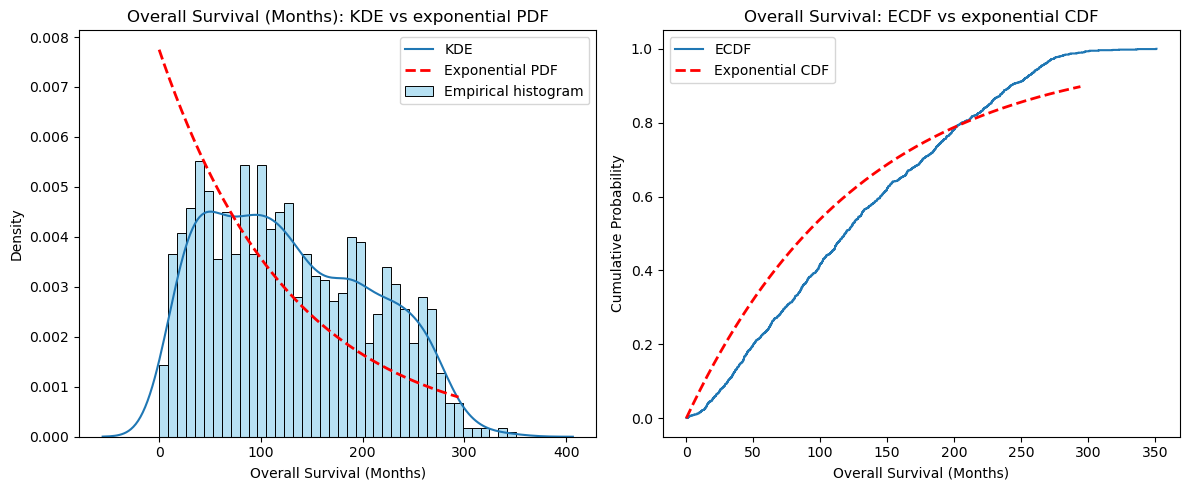

In [172]:
col = 'Overall Survival (Months)'
y = df[col].dropna().astype(float)
y = y[y >= 0].values


loc_hat, scale_hat = stats.expon.fit(y, floc=0)
lambda_hat_scipy = 1.0 / scale_hat
print(f"Scipy fit (with loc=0): scale = {scale_hat:.6f} => lambda = {lambda_hat_scipy:.6f}")

# KDE
xx = np.linspace(0, np.percentile(y, 99), 400)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y, bins=40, stat='density', color='skyblue', alpha=0.6, label='Empirical histogram')

sns.kdeplot(y, bw_method='scott', label='KDE')
plt.plot(xx, lambda_hat_scipy * np.exp(-lambda_hat_scipy * xx), 'r--', lw=2, label='Exponential PDF')
plt.title('Overall Survival (Months): KDE vs exponential PDF')
plt.xlabel(col); plt.ylabel('Density'); plt.legend()

# ECDF
plt.subplot(1,2,2)
ys_sorted = np.sort(y)
ecdf = np.arange(1, len(ys_sorted)+1) / len(ys_sorted)
plt.step(ys_sorted, ecdf, where='post', label='ECDF')
plt.plot(xx, 1 - np.exp(-lambda_hat_scipy * xx), 'r--', lw=2, label='Exponential CDF')
plt.title('Overall Survival: ECDF vs exponential CDF')
plt.xlabel(col); plt.ylabel('Cumulative Probability'); plt.legend()

plt.tight_layout()
plt.show()

## Negative Binomial

### Support

The support of this distribution is as is outlined in the PMF, positive integers $k = 0,1,2,3,4...$

### Plot and Simulation

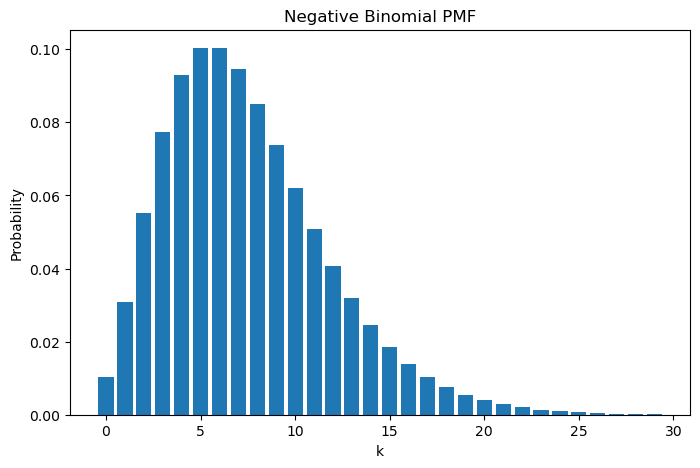

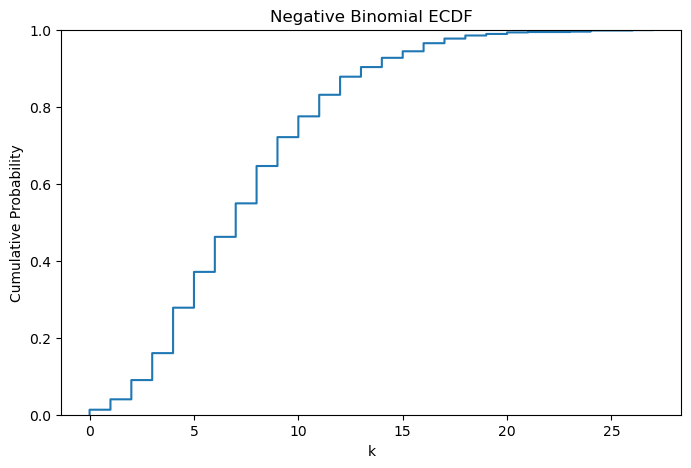

In [176]:
r, p = 5, 0.4
k = np.arange(0, 30)

# PMF
plt.figure(figsize=(8,5))
plt.bar(k, nbinom.pmf(k, r, p))
plt.title('Negative Binomial PMF')
plt.xlabel('k')
plt.ylabel('Probability')
plt.show()

# ECDF
samples = nbinom.rvs(r, p, size=1000)
plt.figure(figsize=(8,5))
sns.ecdfplot(samples)
plt.title('Negative Binomial ECDF')
plt.xlabel('k')
plt.ylabel('Cumulative Probability')
plt.show()

### Metabric Example

I think that the best variable to demonstrate this distribution is Mutation Count beacause it is the most sequential/Poisson style of data in the dataframe.

Sample mean = 5.4944, sample variance = 14.1041
MOM estimates: r = 3.5064, p = 0.3896


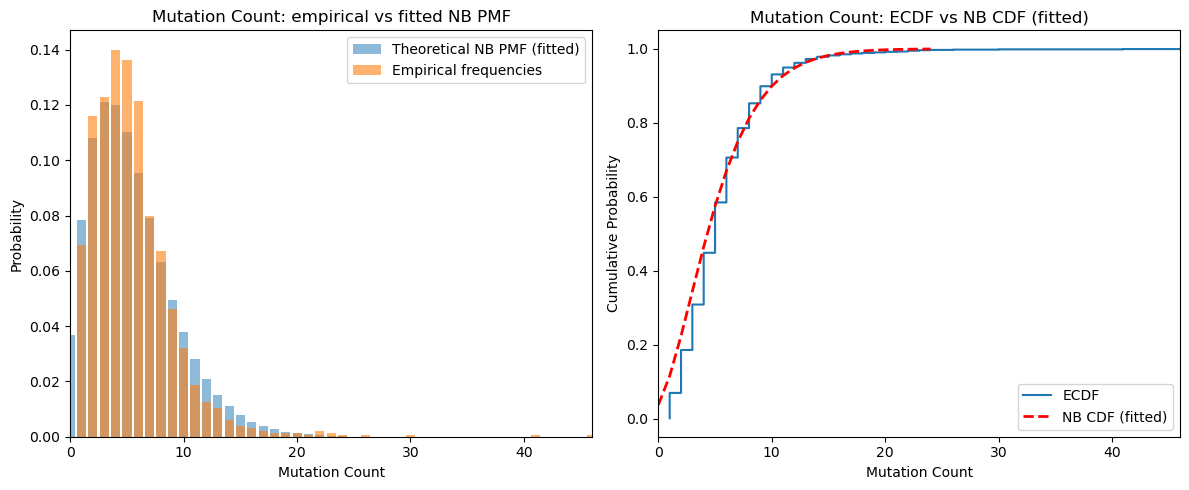

In [177]:
col = 'Mutation Count'
mc = df[col].dropna().astype(int).values

mean_mc = mc.mean()
var_mc = mc.var(ddof=1)
print(f"Sample mean = {mean_mc:.4f}, sample variance = {var_mc:.4f}")

r_hat = (mean_mc**2) / (var_mc - mean_mc)
p_hat = r_hat / (r_hat + mean_mc)
print(f"MOM estimates: r = {r_hat:.4f}, p = {p_hat:.4f}")

k_max = int(min(mc.max(), np.percentile(mc, 99))) + 5
ks = np.arange(0, k_max+1)
pmf_theor = stats.nbinom.pmf(ks, n=r_hat, p=p_hat)

# PMF
vals, counts = np.unique(mc, return_counts=True)
probs_emp = counts / counts.sum()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.bar(ks, pmf_theor, alpha=0.5, label='Theoretical NB PMF (fitted)')
plt.bar(vals, probs_emp, alpha=0.6, label='Empirical frequencies')
plt.xlim(0, max(ks.max(), vals.max()))
plt.xlabel('Mutation Count'); plt.ylabel('Probability'); plt.legend()
plt.title('Mutation Count: empirical vs fitted NB PMF')

# ECDF
plt.subplot(1,2,2)
xs = np.sort(mc)
ecs = np.arange(1, len(xs)+1) / len(xs)
plt.step(xs, ecs, where='post', label='ECDF')
plt.plot(ks, stats.nbinom.cdf(ks, n=r_hat, p=p_hat), 'r--', lw=2, label='NB CDF (fitted)')
plt.xlim(0, max(ks.max(), vals.max()))
plt.xlabel('Mutation Count'); plt.ylabel('Cumulative Probability'); plt.legend()
plt.title('Mutation Count: ECDF vs NB CDF (fitted)')
plt.tight_layout()
plt.show()

## Categorical

### Support

The support of this distribution covers all positive integers through K -- $k $ $\in$ {$1,2,...,K$}

### Plot + Simulation

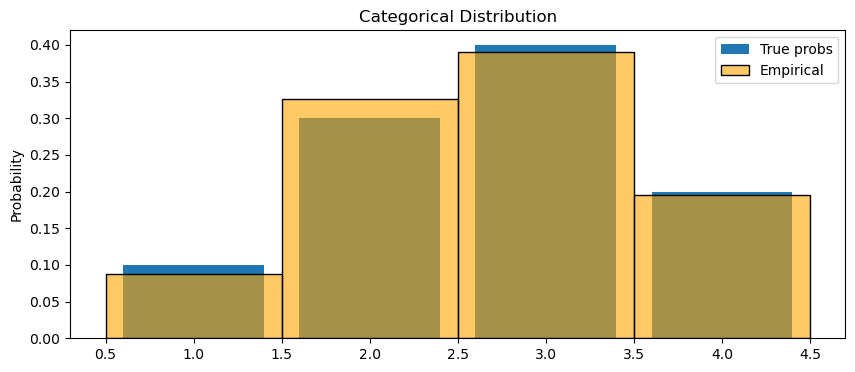

In [178]:
p = [0.1, 0.3, 0.4, 0.2]
K = len(p)
samples = np.random.choice(np.arange(1, K+1), size=1000, p=p)

plt.figure(figsize=(10,4))
plt.bar(np.arange(1,K+1), p, label='True probs')
sns.histplot(samples, stat='probability', discrete=True, color='orange', label='Empirical', alpha=0.6)
plt.title('Categorical Distribution')
plt.legend()
plt.show()

### Metabric Example

I chose Type of Breast Surgery to demonstrate this distribution since it is a categorical variable with multiple different outcomes.

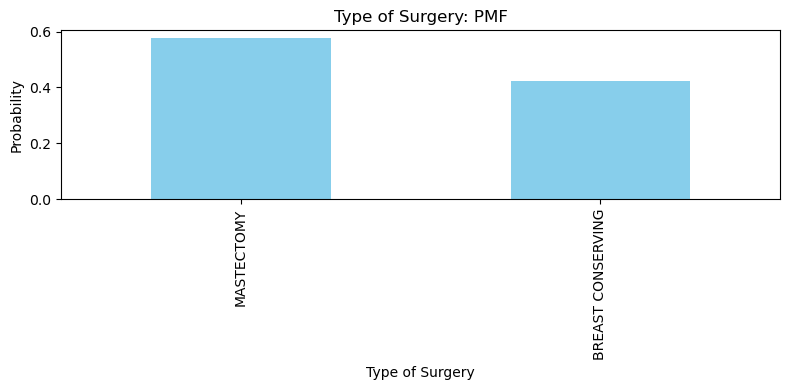

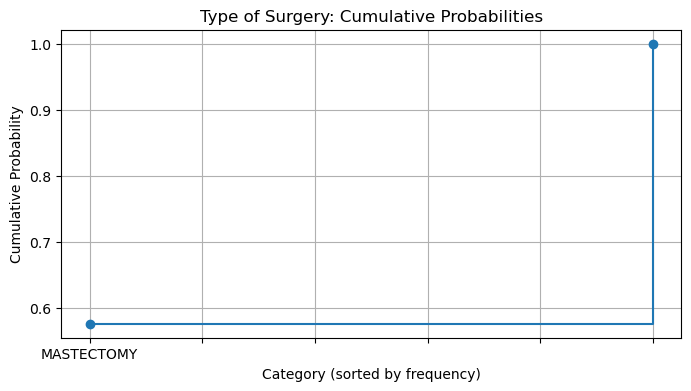

In [181]:
col = 'Type of Breast Surgery'
ct = df[col].dropna().astype(str)
counts = ct.value_counts()
probs = counts / counts.sum()

# PMF as bar chart
plt.figure(figsize=(8,4))
probs.plot(kind='bar', color='skyblue')
plt.title('Type of Surgery: PMF')
plt.ylabel('Probability')
plt.xlabel('Type of Surgery')
plt.tight_layout()
plt.show()

# ECDF-like cumulative probabilities
cum_probs = probs.cumsum()
plt.figure(figsize=(8,4))
cum_probs.plot(drawstyle='steps-post', marker='o')
plt.title('Type of Surgery: Cumulative Probabilities')
plt.ylabel('Cumulative Probability')
plt.xlabel('Category (sorted by frequency)')
plt.grid(True)
plt.show()